# **Library**

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import  train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# **Load Dataset**

In [2]:
data = pd.read_csv(r'./data/Telco_Asah.csv')
data.head(11)

,customer_id,plan_type,device_brand,avg_data_usage_gb,pct_video_usage,avg_call_duration,sms_freq,monthly_spend,topup_freq,travel_score,complaint_count,target_offer
0,C00001,Prepaid,Realme,1.50,0.804146,7.98,13,70000.0,4,0.284419,0,General Offer
1,C00002,Postpaid,Vivo,1.09,0.107686,9.56,9,63000.0,3,0.115086,0,General Offer
2,C00003,Postpaid,Xiaomi,3.24,0.313894,4.61,13,89000.0,7,0.402998,0,General Offer
3,C00004,Prepaid,Apple,5.32,0.420158,6.96,8,67000.0,4,0.302169,0,General Offer
4,C00005,Prepaid,Huawei,1.91,0.251638,11.01,21,72000.0,5,0.487911,0,General Offer
5,C00006,Prepaid,Oppo,3.30,0.478873,6.53,17,54000.0,3,0.372135,0,Top-up Promo
6,C00007,Prepaid,Oppo,9.87,0.375882,11.17,11,140000.0,5,0.308220,1,Device Upgrade Offer
7,C00008,Postpaid,Oppo,13.91,0.465977,7.72,14,180000.0,4,0.288257,2,Device Upgrade Offer
8,C00009,Postpaid,Realme,1.25,0.222178,10.73,20,72000.0,2,0.270601,0,General Offer
9,C00010,Postpaid,Huawei,3.66,0.196774,13.36,11,83000.0,1,0.342730,0,General Offer


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        10000 non-null  object 
 1   plan_type          10000 non-null  object 
 2   device_brand       10000 non-null  object 
 3   avg_data_usage_gb  10000 non-null  float64
 4   pct_video_usage    10000 non-null  float64
 5   avg_call_duration  10000 non-null  float64
 6   sms_freq           10000 non-null  int64  
 7   monthly_spend      10000 non-null  float64
 8   topup_freq         10000 non-null  int64  
 9   travel_score       10000 non-null  float64
 10  complaint_count    10000 non-null  int64  
 11  target_offer       10000 non-null  object 
dtypes: float64(5), int64(3), object(4)
memory usage: 937.6+ KB


In [4]:
data.describe(include='all')

,customer_id,plan_type,device_brand,avg_data_usage_gb,pct_video_usage,avg_call_duration,sms_freq,monthly_spend,topup_freq,travel_score,complaint_count,target_offer
count,10000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000
unique,10000,2,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
top,C09984,Prepaid,Realme,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,General Offer
freq,1,6108,1509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6070
mean,NaN,NaN,NaN,5.958883,0.402639,9.971357,15.010800,109776.500000,2.986600,0.282441,0.492600,NaN
std,NaN,NaN,NaN,4.192909,0.195741,4.954993,3.872775,46237.321903,1.709828,0.158366,0.704127,NaN
min,NaN,NaN,NaN,0.030000,0.000000,-8.370000,4.000000,-13000.000000,0.000000,0.003376,0.000000,NaN
25%,NaN,NaN,NaN,2.870000,0.265290,6.650000,12.000000,78000.000000,2.000000,0.158775,0.000000,NaN
50%,NaN,NaN,NaN,4.990000,0.400116,10.020000,15.000000,102000.000000,3.000000,0.261206,0.000000,NaN
75%,NaN,NaN,NaN,8.040000,0.535161,13.320000,18.000000,135000.000000,4.000000,0.385656,1.000000,NaN


In [5]:
data['target_offer'].value_counts()

target_offer
General Offer             6070
Device Upgrade Offer      1502
Data Booster               797
Retention Offer            761
Top-up Promo               370
Streaming Partner Pack     258
Roaming Pass                93
Family Plan Offer           81
Voice Bundle                68
Name: count, dtype: int64

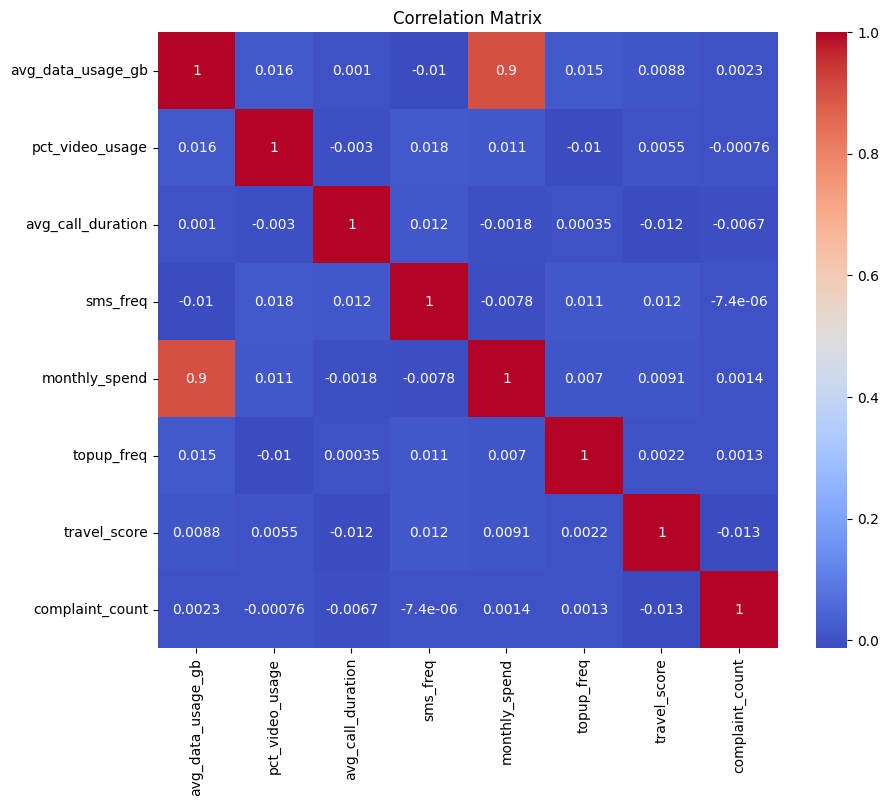

In [6]:
numeric_features = data.select_dtypes(include=['float64','int64']).columns
corr_matrix = data[numeric_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

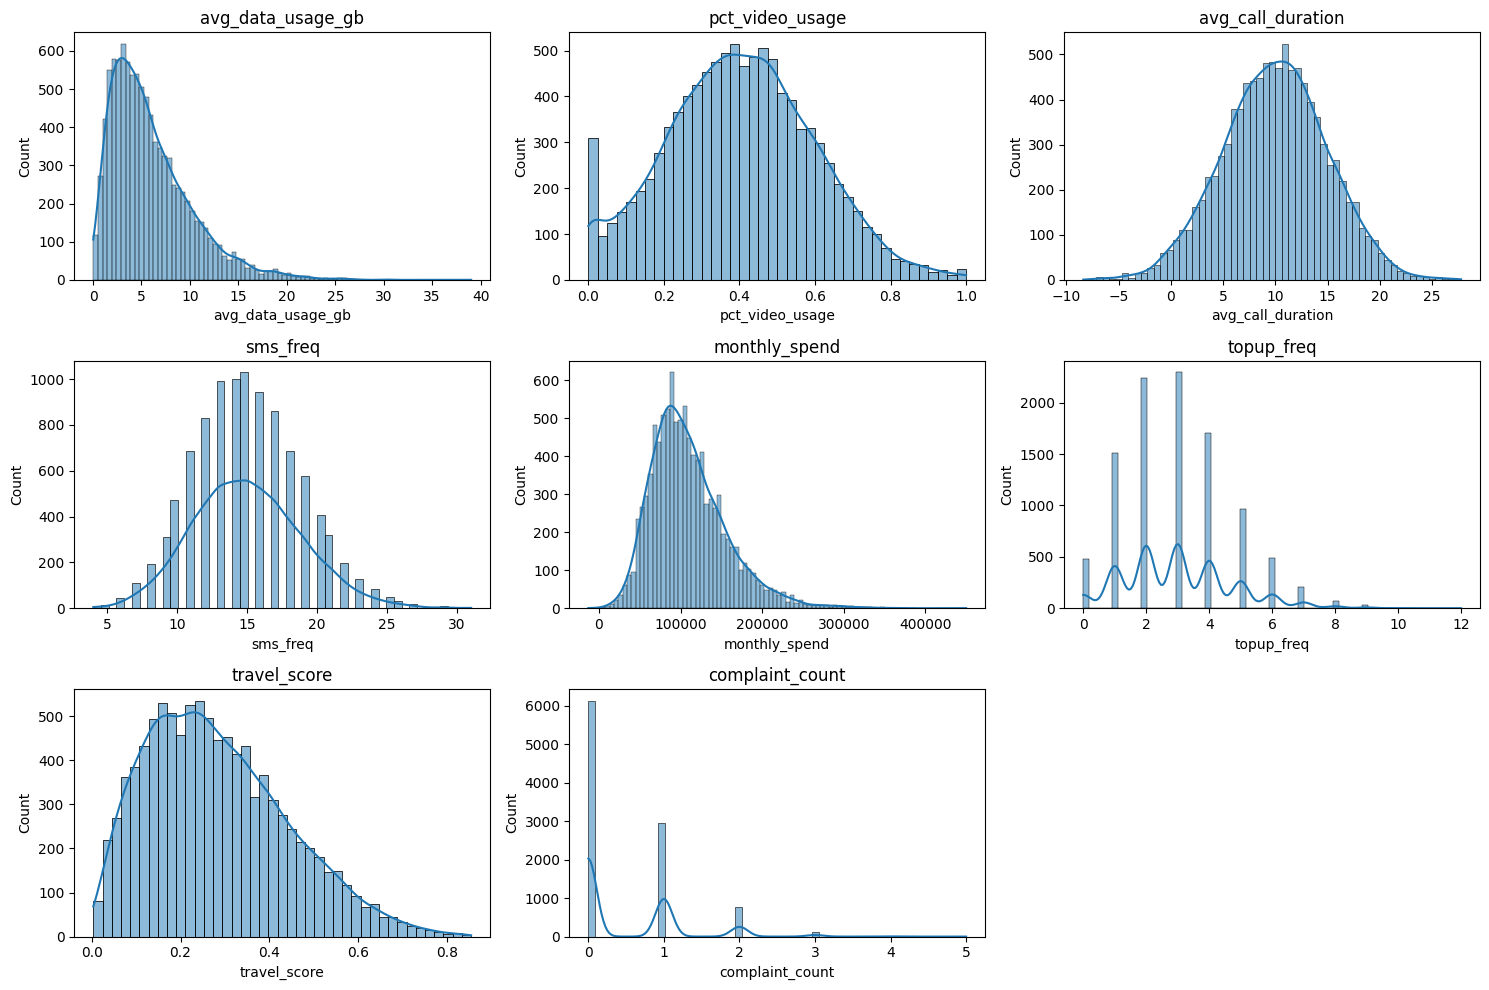

In [7]:
numeric_cols = data.select_dtypes(include=['float64','int64']).columns
plt.figure(figsize=(15,10))
for i, kolom in enumerate(numeric_cols):
  plt.subplot(3,3,i + 1)
  sns.histplot(data=data[kolom], kde=True)
  plt.title(kolom)
plt.tight_layout()
plt.show()

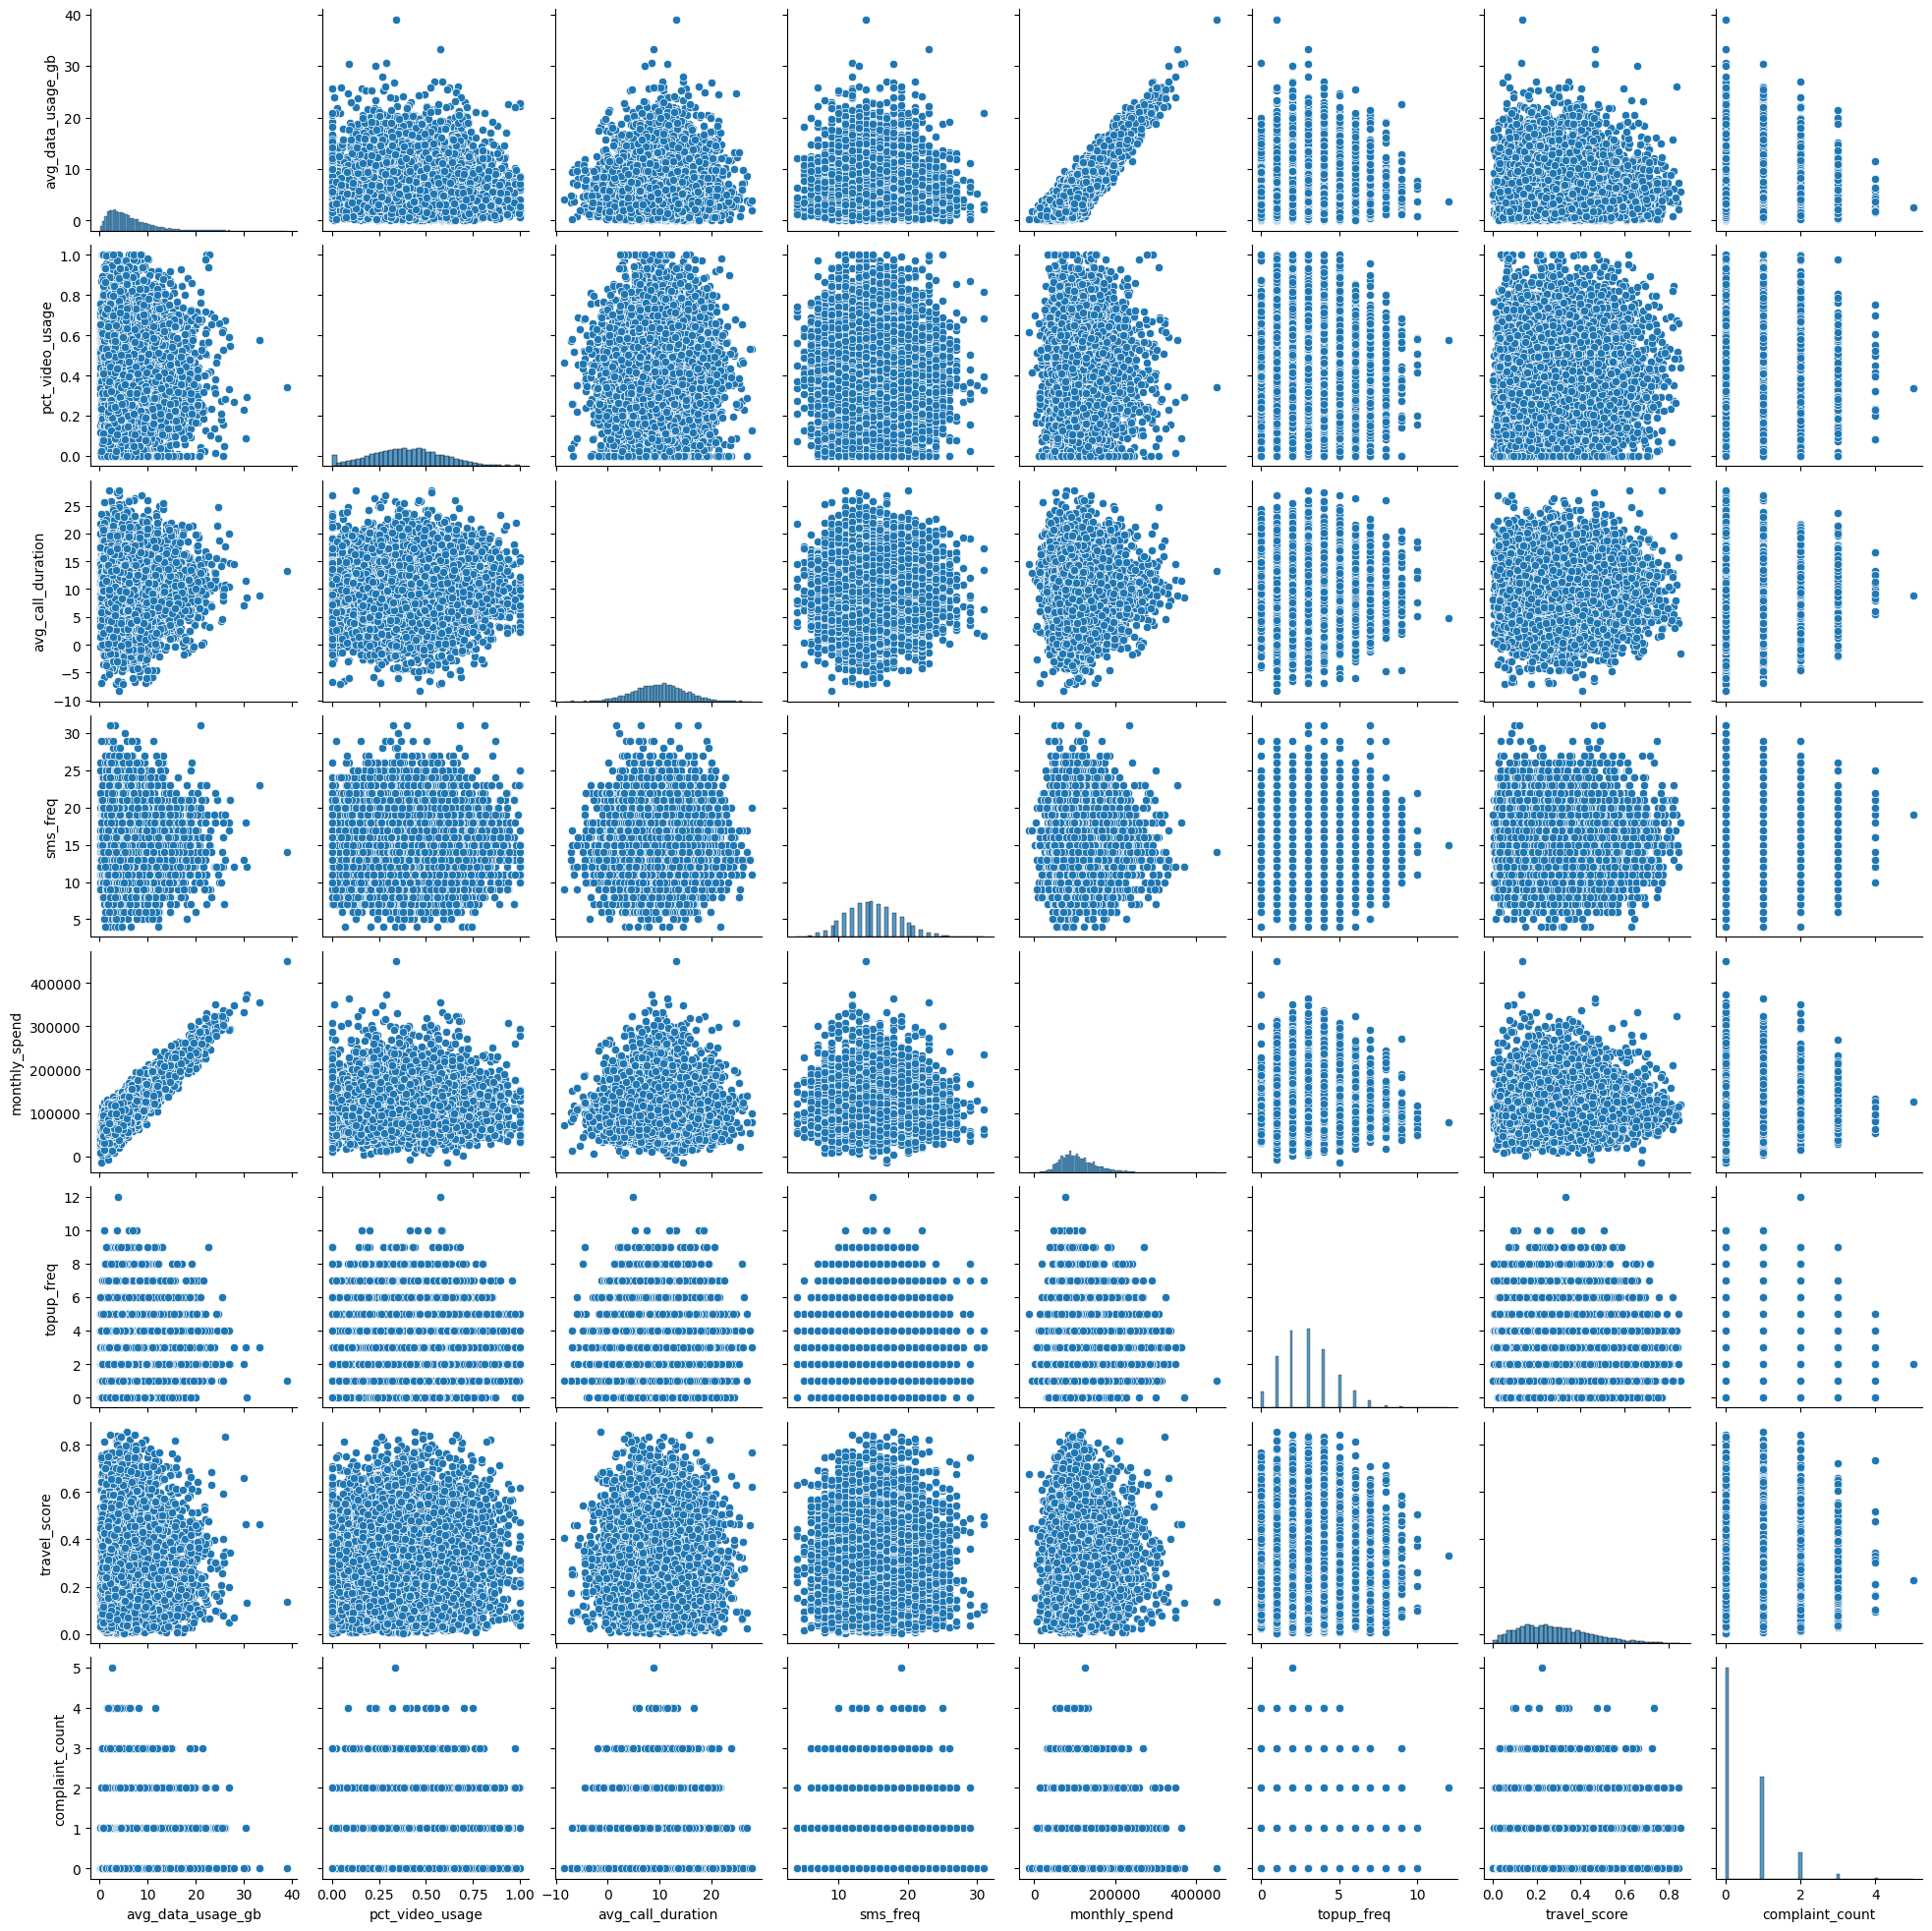

In [ ]:
sns.pairplot(data)

In [8]:
pd.options.display.max_columns = None
pd.options.display.max_rows = None

# **Preprocessing Data**

In [16]:
data_standard = data.drop(columns=['customer_id'], axis=1)
data_standard.head(21)

,plan_type,device_brand,avg_data_usage_gb,pct_video_usage,avg_call_duration,sms_freq,monthly_spend,topup_freq,travel_score,complaint_count,target_offer
0,Prepaid,Realme,1.50,0.804146,7.98,13,70000.0,4,0.284419,0,General Offer
1,Postpaid,Vivo,1.09,0.107686,9.56,9,63000.0,3,0.115086,0,General Offer
2,Postpaid,Xiaomi,3.24,0.313894,4.61,13,89000.0,7,0.402998,0,General Offer
3,Prepaid,Apple,5.32,0.420158,6.96,8,67000.0,4,0.302169,0,General Offer
4,Prepaid,Huawei,1.91,0.251638,11.01,21,72000.0,5,0.487911,0,General Offer
5,Prepaid,Oppo,3.30,0.478873,6.53,17,54000.0,3,0.372135,0,Top-up Promo
6,Prepaid,Oppo,9.87,0.375882,11.17,11,140000.0,5,0.308220,1,Device Upgrade Offer
7,Postpaid,Oppo,13.91,0.465977,7.72,14,180000.0,4,0.288257,2,Device Upgrade Offer
8,Postpaid,Realme,1.25,0.222178,10.73,20,72000.0,2,0.270601,0,General Offer
9,Postpaid,Huawei,3.66,0.196774,13.36,11,83000.0,1,0.342730,0,General Offer


In [17]:
data_standard['device_brand'].value_counts()

device_brand
Realme     1509
Xiaomi     1458
Samsung    1439
Huawei     1438
Vivo       1395
Apple      1386
Oppo       1375
Name: count, dtype: int64

In [18]:
data_standard['target_offer'].value_counts()

target_offer
General Offer             6070
Device Upgrade Offer      1502
Data Booster               797
Retention Offer            761
Top-up Promo               370
Streaming Partner Pack     258
Roaming Pass                93
Family Plan Offer           81
Voice Bundle                68
Name: count, dtype: int64

In [19]:
data_standard['plan_type'].value_counts()

plan_type
Prepaid     6108
Postpaid    3892
Name: count, dtype: int64

In [20]:
# Handling outlier
X = data_standard.drop(columns=['target_offer'])
y = data_standard['target_offer']

numeric_cols = X.select_dtypes(include=['float64','int64']).columns

Q1 = X[numeric_cols].quantile(0.25)
Q3 = X[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

kondisi_outlier = ~((X[numeric_cols] < (Q1 - 1.5 * IQR)) | (X[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
data_clean_standard = X[kondisi_outlier]

print(f"Data Sebelum Dihapus Outlier : {len(data_standard)}")
print(f"Data Setelah Dihapus Outlier : {len(data_clean_standard)}")

Data Sebelum Dihapus Outlier : 10000
Data Setelah Dihapus Outlier : 9231


In [21]:
X = X[kondisi_outlier]
y = y[kondisi_outlier]

In [22]:
# Identifikasi fitur kategori & numerik
categotical_features = X.select_dtypes(include=['object']).columns.to_list()
numeric_features = X.select_dtypes(include=['float64','int64']).columns.to_list()

Custom Transformer

In [56]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categotical_features),
        ('num', StandardScaler(), numeric_features)
    ],
    remainder="passthrough"
)

# **Data Splitting**

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [58]:
unique, counts = np.unique(y_train, return_counts=True)
dict(zip(unique, counts))

{'Data Booster': np.int64(526),
 'Device Upgrade Offer': np.int64(1058),
 'Family Plan Offer': np.int64(58),
 'General Offer': np.int64(4683),
 'Retention Offer': np.int64(518),
 'Roaming Pass': np.int64(23),
 'Streaming Partner Pack': np.int64(200),
 'Top-up Promo': np.int64(279),
 'Voice Bundle': np.int64(39)}

# **Balancing Data**

In [59]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [60]:
import numpy as np
unique, counts = np.unique(y_train_bal, return_counts=True)
dict(zip(unique, counts))

{'Data Booster': np.int64(4683),
 'Device Upgrade Offer': np.int64(4683),
 'Family Plan Offer': np.int64(4683),
 'General Offer': np.int64(4683),
 'Retention Offer': np.int64(4683),
 'Roaming Pass': np.int64(4683),
 'Streaming Partner Pack': np.int64(4683),
 'Top-up Promo': np.int64(4683),
 'Voice Bundle': np.int64(4683)}

# **Modelling**

In [61]:
model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('classifier', RandomForestClassifier(n_estimators=200, class_weight='balanced',random_state=42))
])
model.fit(X_train_bal, y_train_bal)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['plan_type',
                                                   'device_brand']),
                                                 ('num', StandardScaler(),
                                                  ['avg_data_usage_gb',
                                                   'pct_video_usage',
                                                   'avg_call_duration',
                                                   'sms_freq', 'monthly_spend',
                                                   'topup_freq', 'travel_score',
                                                   'complaint_count'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

# **Evaluasi Model**

In [62]:
y_pred = model.predict(X_test)

In [63]:
def print_evaluate(model, X_test, y_test):
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred, average='weighted')
  recall = recall_score(y_test, y_pred, average='weighted')
  f1 = f1_score(y_test, y_pred, average='weighted')
  print(f"Accuracy: {accuracy}")
  print(f"Precision: {precision}")
  print(f"Recall: {recall}")
  print(f"F1 Score: {f1}")
  print(classification_report(y_test, y_pred))

print_evaluate(model, X_test, y_test)

Accuracy: 0.9658906334596643
Precision: 0.9690279891398125
Recall: 0.9658906334596643
F1 Score: 0.9665976644152183
                        precision    recall  f1-score   support

          Data Booster       0.99      0.97      0.98       132
  Device Upgrade Offer       0.85      0.97      0.91       265
     Family Plan Offer       0.93      0.93      0.93        15
         General Offer       1.00      0.96      0.98      1171
       Retention Offer       0.93      0.98      0.96       129
          Roaming Pass       1.00      1.00      1.00         6
Streaming Partner Pack       0.92      0.98      0.95        50
          Top-up Promo       1.00      0.96      0.98        70
          Voice Bundle       1.00      0.78      0.88         9

              accuracy                           0.97      1847
             macro avg       0.96      0.95      0.95      1847
          weighted avg       0.97      0.97      0.97      1847



# **Save Model**

In [64]:
import joblib
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
joblib.dump(model, "model_rf.joblib")

['model_rf.joblib']

In [33]:
model = joblib.load("model_rf.joblib")